In [2]:
import numpy as np
import matplotlib.pyplot as plt
import maglab
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd

In [3]:
def get_spin(file_path="path_file"):
    file_path = file_path
    dx = 1.06e-9
    geo = maglab.geo.cylider(136, 111)
    nx, ny, nz = geo.shape
    micro = maglab.Micro(nx, ny, nz, dx)
    state = micro.load_state(f"{file_path}/final.pth")
    spin = state.spin
    return spin, nx, ny, nz

def compute_angles_vectorized(spin_tensor: torch.Tensor, target_z: int, angles_degrees: torch.Tensor, 
                              target_mz: float = 0.0, start_point=None):
    """
    Calculate the angle between all m_xy vectors and the tangent.
    start_point: optional parameter, if provided, use the given start point; otherwise, compute the start point.
    """
    if spin_tensor.dim() != 4 or spin_tensor.shape[0] != 3:
        raise ValueError("Input tensor shape must be (3, nx, ny, nz)")

    device = spin_tensor.device
    spin = spin_tensor.detach()

    mx_slice = spin[0, :, :, target_z]  # (nx, ny)
    my_slice = spin[1, :, :, target_z]  # (nx, ny)
    mz_slice = spin[2, :, :, target_z]  # (nx, ny)
    _, nx, ny, nz = spin.shape

    if start_point is not None:
        start_x, start_y = start_point
    else:
        cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0
        cx_int, cy_int = int(round(cx)), int(round(cy))

        mz_np = mz_slice.cpu().numpy()  # (nx, ny)
        high_mz_indices = np.where(mz_np >= 0.99)
        
        N_limit = 30    # the size of the center area to restrict high mz values
        N_half = N_limit // 2
        ix_start = max(0, cx_int - N_half)
        ix_end = min(nx, cx_int + N_half)
        iy_start = max(0, cy_int - N_half)
        iy_end = min(ny, cy_int + N_half)

        valid_mask = (high_mz_indices[0] >= ix_start) & (high_mz_indices[0] < ix_end) & \
                     (high_mz_indices[1] >= iy_start) & (high_mz_indices[1] < iy_end)
        
        filtered_ix = high_mz_indices[0][valid_mask]
        filtered_iy = high_mz_indices[1][valid_mask]
        
        if filtered_ix.size == 0:
            start_x, start_y = cx, cy 
            print(f"Warning: No high mz region found for z={target_z}, using center point.")
        else:
            start_x = np.mean(filtered_ix)
            start_y = np.mean(filtered_iy)

    start_x_gpu = torch.tensor(start_x, device=device, dtype=torch.float32)
    start_y_gpu = torch.tensor(start_y, device=device, dtype=torch.float32)

    angles_rad = torch.deg2rad(angles_degrees)
    cos_a = torch.cos(angles_rad)
    sin_a = torch.sin(angles_rad)

    r_max = max(nx, ny) * 1.5
    r_values = torch.linspace(0.1, r_max, 200, device=device)

    angles_result = torch.full((len(angles_degrees),), float('nan'), device=device)

    mz_gpu = mz_slice.to(device)
    mx_gpu = mx_slice.to(device)
    my_gpu = my_slice.to(device)

    nx_tensor = torch.tensor(nx, device=device, dtype=torch.float32)
    ny_tensor = torch.tensor(ny, device=device, dtype=torch.float32)

    batch_size = 32 
    for i in range(0, len(angles_degrees), batch_size):
        end_idx = min(i + batch_size, len(angles_degrees))
        batch_cos = cos_a[i:end_idx]
        batch_sin = sin_a[i:end_idx]
    
        batch_results = []
        for j in range(len(batch_cos)):
            cos_val = batch_cos[j]
            sin_val = batch_sin[j]

            x_coords = start_x_gpu + r_values * cos_val
            y_coords = start_y_gpu + r_values * sin_val

            valid_mask = (x_coords >= 0) & (x_coords < nx_tensor) & (y_coords >= 0) & (y_coords < ny_tensor)
            valid_indices = torch.where(valid_mask)[0]
            
            if len(valid_indices) == 0:
                batch_results.append(float('nan'))
                continue

            x_valid = x_coords[valid_indices]
            y_valid = y_coords[valid_indices]
            
            # Sample mz values (bilinear interpolation) and normalize the coordinates to [-1, 1]
            x_norm = (x_valid / (nx_tensor - 1)) * 2 - 1  
            y_norm = (y_valid / (ny_tensor - 1)) * 2 - 1  

            grid = torch.stack([y_norm.unsqueeze(1), x_norm.unsqueeze(1)], dim=-1).unsqueeze(0)
            mz_samples = torch.nn.functional.grid_sample(
                mz_gpu.unsqueeze(0).unsqueeze(0),  # (1, 1, nx, ny)
                grid,  # (1, N, 1, 2)
                mode='bilinear',
                align_corners=True,
                padding_mode='border'
            ).squeeze()  # (N,)

            cross_mask = mz_samples <= target_mz
            
            if cross_mask.any():
                first_cross_idx = torch.where(cross_mask)[0][0]
                if first_cross_idx > 0:
                    ix_prev = int(torch.round(x_valid[first_cross_idx - 1]).item())
                    iy_prev = int(torch.round(y_valid[first_cross_idx - 1]).item())

                    ix_prev = min(max(ix_prev, 0), nx - 1)
                    iy_prev = min(max(iy_prev, 0), ny - 1)

                    mx_val = mx_gpu[ix_prev, iy_prev]
                    my_val = my_gpu[ix_prev, iy_prev]

                    R_x = torch.tensor(ix_prev, device=device, dtype=torch.float32) - start_x_gpu
                    R_y = torch.tensor(iy_prev, device=device, dtype=torch.float32) - start_y_gpu
                    
                    T_x = R_y
                    T_y = -R_x
                    
                    norm_T = torch.sqrt(T_x**2 + T_y**2)
                    if norm_T > 0:
                        T_x_norm = T_x / norm_T
                        T_y_norm = T_y / norm_T
                    else:
                        T_x_norm = torch.tensor(0.0, device=device)
                        T_y_norm = torch.tensor(0.0, device=device)

                    m_xy_magnitude = torch.sqrt(mx_val**2 + my_val**2)
                    if m_xy_magnitude > 0:
                        mx_norm = mx_val / m_xy_magnitude
                        my_norm = my_val / m_xy_magnitude
                    else:
                        mx_norm = torch.tensor(0.0, device=device)
                        my_norm = torch.tensor(0.0, device=device)

                    dot_product = T_x_norm * mx_norm + T_y_norm * my_norm
                    cross_product = T_x_norm * my_norm - T_y_norm * mx_norm
                    
                    angle_rad = torch.atan2(cross_product, dot_product)
                    angle_deg = torch.rad2deg(angle_rad)
                    
                    # Angle limited to [-180, 180]
                    angle_deg = angle_deg.item()
                    if angle_deg > 180:
                        angle_deg -= 360
                    elif angle_deg < -180:
                        angle_deg += 360
                    
                    batch_results.append(angle_deg)
                else:
                    batch_results.append(float('nan'))
            else:
                batch_results.append(float('nan'))
        angles_result[i:end_idx] = torch.tensor(batch_results, device=device)
    return angles_result.cpu().numpy(), (start_x, start_y)

def compute_angles_for_all_nz(spin_tensor_gpu, target_z_base=55, angles_range=(0, 360, 1)):
    start_angle, end_angle, step_angle = angles_range
    angles_degrees = torch.arange(start_angle, end_angle, step_angle, dtype=torch.float32, device=spin_tensor_gpu.device)
    _, nx, ny, nz_total = spin_tensor_gpu.shape

    nz_angles_list = []
    try:
        angles_base, start_point = compute_angles_vectorized(spin_tensor_gpu, target_z_base, angles_degrees)
        valid_angles_base = [a for a in angles_base if not np.isnan(a)]
        
        if len(valid_angles_base) > 0:
            mean_angle_base = np.mean(valid_angles_base)
            nz_angles_list.append({'nz': target_z_base, 'angle': mean_angle_base})
        else:
            mean_angle_base = float('nan')
            nz_angles_list.append({'nz': target_z_base, 'angle': mean_angle_base})
            print(f"z={target_z_base}: No valid angles found")
 
        downward_start_point = start_point
        upward_start_point = start_point
        
    except Exception as e:
        print(f"Error computing for z={target_z_base}: {e}")
        center_point = ((nx - 1) / 2.0, (ny - 1) / 2.0)
        downward_start_point = center_point
        upward_start_point = center_point
        nz_angles_list.append({'nz': target_z_base, 'angle': float('nan')})
    
    # Traverse downward
    print("\nComputing downward from z=54 to z=0...")
    for z in range(target_z_base-1, -1, -1):
        try:
            angles_z, start_point_z = compute_angles_vectorized(spin_tensor_gpu, z, angles_degrees, start_point=downward_start_point)
            valid_angles_z = [a for a in angles_z if not np.isnan(a)]
            
            if len(valid_angles_z) > 0:
                mean_angle_z = np.mean(valid_angles_z)
                nz_angles_list.append({'nz': z, 'angle': mean_angle_z})
                downward_start_point = start_point_z
            else:
                mean_angle_z = float('nan')
                nz_angles_list.append({'nz': z, 'angle': mean_angle_z})
                print(f"No valid angles found")
                # keep downward_start_point
                
        except Exception as e:
            print(f"Error: {e}")
            nz_angles_list.append({'nz': z, 'angle': float('nan')})
    
    # Traverse upward
    print(f"\nComputing upward from z={target_z_base+1} to z={nz_total-1}...")
    for z in range(target_z_base+1, nz_total):
        try:
            angles_z, start_point_z = compute_angles_vectorized(spin_tensor_gpu, z, angles_degrees, start_point=upward_start_point)
            valid_angles_z = [a for a in angles_z if not np.isnan(a)]
            
            if len(valid_angles_z) > 0:
                mean_angle_z = np.mean(valid_angles_z)
                nz_angles_list.append({'nz': z, 'angle': mean_angle_z})
                upward_start_point = start_point_z
            else:
                mean_angle_z = float('nan')
                nz_angles_list.append({'nz': z, 'angle': mean_angle_z})
                print(f"No valid angles found")
                # keep upward_start_point
                
        except Exception as e:
            print(f"Error: {e}")
            nz_angles_list.append({'nz': z, 'angle': float('nan')})
   
    # sorted by nz
    nz_angles_list.sort(key=lambda x: x['nz'])
    return nz_angles_list

def plot_twist_angles(csv_file_path, highlight_z=55, save_path=None):
    """
    Read CSV file and plot nz-angle line chart.

    csv_file_path: path to the CSV file
    highlight_z: the z layer to highlight 
    save_path: optional, path to save the image
    """

    try:
        df = pd.read_csv(csv_file_path)
    except FileNotFoundError:
        print(f"error: not found {csv_file_path}")
        return
    except Exception as e:
        print(f"error reading file: {e}")
        return

    if 'nz' not in df.columns or 'angle' not in df.columns:
        print("Error: The CSV file must contain 'nz' and 'angle' columns.")
        print(f"Current column names: {df.columns.tolist()}")
        return
    
    # sorted by nz
    df = df.sort_values('nz')

    valid_df = df[~df['angle'].isna()]
    invalid_df = df[df['angle'].isna()]

    print(f"total data points: {len(df)}")
    print(f"valid data points: {len(valid_df)}")
    print(f"invalid data points (NaN): {len(invalid_df)}")
    
    if len(valid_df) == 0:
        print("error: No valid data available to plot")
        return

    plt.figure(figsize=(12, 8))
    plt.plot(valid_df['nz'], valid_df['angle'], 
             marker='o', linestyle='-', linewidth=2, markersize=6,
             color='steelblue', alpha=0.8, label='valid angle data')

    if len(invalid_df) > 0:
        plt.scatter(invalid_df['nz'], [0] * len(invalid_df), 
                   marker='x', color='red', s=50, alpha=0.7,
                   label=f'invalid angle (a total of {len(invalid_df)})')

    if highlight_z in valid_df['nz'].values:
        highlight_row = valid_df[valid_df['nz'] == highlight_z].iloc[0]
        plt.scatter(highlight_row['nz'], highlight_row['angle'], 
                   color='red', s=150, zorder=5, 
                   marker='*', edgecolors='black', linewidth=1.5,
                   label=f'base layer z={highlight_z}')

        plt.annotate(f'z={highlight_z}\n{highlight_row["angle"]:.2f}°',
                    xy=(highlight_row['nz'], highlight_row['angle']),
                    xytext=(10, 20),
                    textcoords='offset points',
                    fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8),
                    arrowprops=dict(arrowstyle='->', color='black'))

    plt.xlabel('z (nm)', fontsize=12, fontweight='bold')
    plt.ylabel('Twist angle ($^o$)', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5, which='both')
    plt.legend(loc='best', fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n image has been saved to : {save_path}")

    plt.show()
    return df, valid_df

def plot_twist_comparison(csv_files, labels=None, save_path=None):
    """
    Plot comparison of twist angles from multiple CSV files
   
    csv_files: list of CSV file paths
    labels: list of corresponding labels
    save_path: optional, path to save the image
    """
    
    if labels is None:
        labels = [f'data list{i+1}' for i in range(len(csv_files))]
    
    plt.figure(figsize=(14, 8))
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(csv_files)))
    
    all_data = []
    
    for i, (csv_file, label, color) in enumerate(zip(csv_files, labels, colors)):
        try:
            df = pd.read_csv(csv_file)
            df = df.sort_values('nz')
            valid_df = df[~df['angle'].isna()]
            
            if len(valid_df) > 0:
                plt.plot(valid_df['nz'], valid_df['angle'], 
                        marker='o', linestyle='-', linewidth=2, markersize=5,
                        color=color, alpha=0.7, label=label)

                all_data.append({
                    'label': label,
                    'data': valid_df,
                    'mean': valid_df['angle'].mean(),
                    'std': valid_df['angle'].std()
                })
                
                print(f"{label}: a total of {len(valid_df)} valid data points, mean angle={valid_df['angle'].mean():.2f}°")
            else:
                print(f"{label}: not have valid data to plot")
                
        except Exception as e:
            print(f"error reading {csv_file}: {e}")
    
    if not all_data:
        print("not have valid data to plot")
        return

    plt.xlabel('z (nm)', fontsize=12, fontweight='bold')
    plt.ylabel('Twist angle ($^o$)', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='best', fontsize=10)
    plt.xticks(rotation=45)
    
    # # 添加统计信息表
    # if len(all_data) > 1:
    #     stats_text = "统计汇总:\n"
    #     for data in all_data:
    #         stats_text += f"{data['label']}: {data['mean']:.2f}±{data['std']:.2f}°\n"
        
    #     plt.text(0.02, 0.98, stats_text,
    #             transform=plt.gca().transAxes,
    #             fontsize=9,
    #             verticalalignment='top',
    #             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nimage has been saved to : {save_path}")
    
    plt.show()
    
    return all_data


In [ ]:
losses = list(range(0,21,2))
for l in losses:
    if l == 0:
        file_path = f'..\\recon-scripts\\test_phi\\results\\loss{l:.1e}_wphi1.0e+07'
    else:
        file_path = f'..\\recon-scripts\\dmi_loss\\{l:g}_layers_loss\\results\\loss{l:.1e}_wphi1.0e+07'

    spin_tensor, nx, ny, nz = get_spin(file_path)
    spin_tensor_gpu = spin_tensor.cuda()

    target_z_base = 55
    nz_angles_list = compute_angles_for_all_nz(spin_tensor_gpu, target_z_base, angles_range=(0, 360, 1))

    df = pd.DataFrame(nz_angles_list)
    df.to_csv(f'{file_path}/{l}loss_twist_angle.csv', index=False)
    print(f"\n Twist angle data has been saved to: {l}loss_twist_angle.csv")
    


Computing downward from z=54 to z=0...

Computing upward from z=56 to z=110...
No valid angles found
No valid angles found
No valid angles found
No valid angles found

 Twist angle data has been saved to: 0loss_twist_angle.csv

Computing downward from z=54 to z=0...

Computing upward from z=56 to z=110...

 Twist angle data has been saved to: 2loss_twist_angle.csv

Computing downward from z=54 to z=0...

Computing upward from z=56 to z=110...

 Twist angle data has been saved to: 4loss_twist_angle.csv

Computing downward from z=54 to z=0...

Computing upward from z=56 to z=110...

 Twist angle data has been saved to: 6loss_twist_angle.csv

Computing downward from z=54 to z=0...

Computing upward from z=56 to z=110...

 Twist angle data has been saved to: 8loss_twist_angle.csv

Computing downward from z=54 to z=0...

Computing upward from z=56 to z=110...

 Twist angle data has been saved to: 10loss_twist_angle.csv

Computing downward from z=54 to z=0...

Computing upward from z=56 to 

0: a total of 107 valid data points, mean angle=1.87°
2: a total of 111 valid data points, mean angle=1.59°
4: a total of 111 valid data points, mean angle=1.41°
6: a total of 111 valid data points, mean angle=1.36°
8: a total of 111 valid data points, mean angle=1.69°
10: a total of 111 valid data points, mean angle=1.45°
12: a total of 111 valid data points, mean angle=1.52°
14: a total of 111 valid data points, mean angle=1.57°
16: a total of 111 valid data points, mean angle=1.44°
18: a total of 111 valid data points, mean angle=1.21°
20: a total of 111 valid data points, mean angle=0.82°


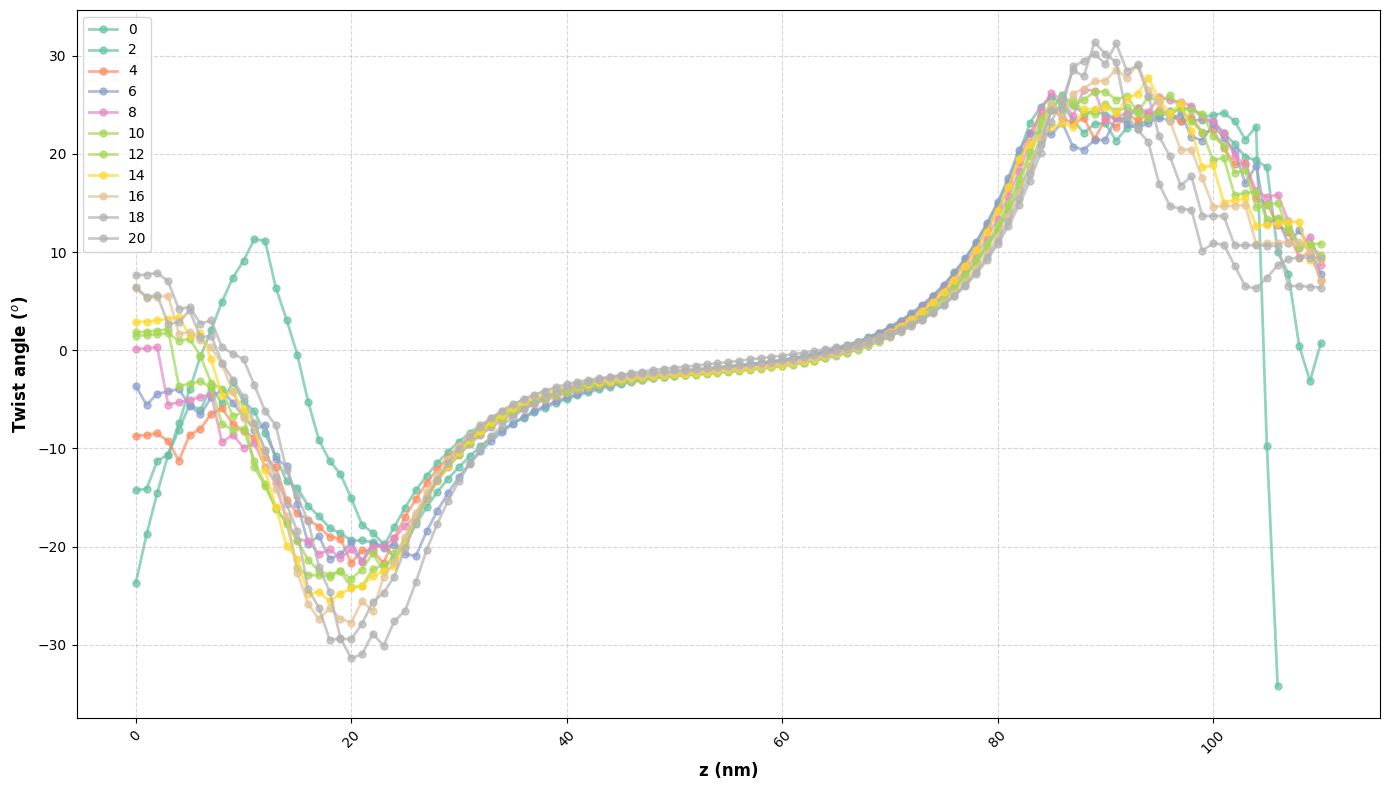

[{'label': 0,
  'data':       nz      angle
  0      0 -23.711895
  1      1 -18.764221
  2      2 -14.512759
  3      3 -10.665458
  4      4  -7.463630
  ..   ...        ...
  102  102  23.322422
  103  103  21.455057
  104  104  22.764772
  105  105  -9.740251
  106  106 -34.200848
  
  [107 rows x 2 columns],
  'mean': np.float64(1.8717313647600953),
  'std': 13.868616293800613},
 {'label': 2,
  'data':       nz      angle
  0      0 -14.231744
  1      1 -14.141521
  2      2 -11.254168
  3      3 -10.668939
  4      4  -8.085259
  ..   ...        ...
  106  106  10.046490
  107  107   7.738477
  108  108   0.439341
  109  109  -3.144027
  110  110   0.691939
  
  [111 rows x 2 columns],
  'mean': np.float64(1.588402798018018),
  'std': 13.245622105983552},
 {'label': 4,
  'data':       nz      angle
  0      0  -8.717685
  1      1  -8.645766
  2      2  -8.462995
  3      3  -9.275354
  4      4 -11.257106
  ..   ...        ...
  106  106  12.793761
  107  107  11.990476
  108  

In [6]:
# csv_file = f"{file_path}/{l:g}loss_twist_angle.csv" 
# plot_nz_angles(csv_file, highlight_z=55) # type: ignore

csv_files = []
for l in losses:
    if l == 0:
        file_path = f'..\\recon-scripts\\test_phi\\results\\loss{l:.1e}_wphi1.0e+07'
    else:
        file_path = f'..\\recon-scripts\\dmi_loss\\{l:g}_layers_loss\\results\\loss{l:.1e}_wphi1.0e+07'
    csv_file = f"{file_path}/{l:g}loss_twist_angle.csv"
    csv_files.append(csv_file)

plot_twist_comparison(csv_files, losses)  # type: ignore

Intersection found at index: (82, 82) with $m_z$=0.059

Angle Calculation:
  Tangent Vector (normalized): (0.707, -0.707)
  m_xy Vector (normalized): (0.117, -0.993)
  Dot Product: 0.785
  Cross Product: -0.619
  Angle between vectors: -38.26°


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17300\1875396549.py:211: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  start_scatter = plt.scatter(start_x, start_y, color='yellow', marker='x', s=150, linewidths=3, edgecolors='black')


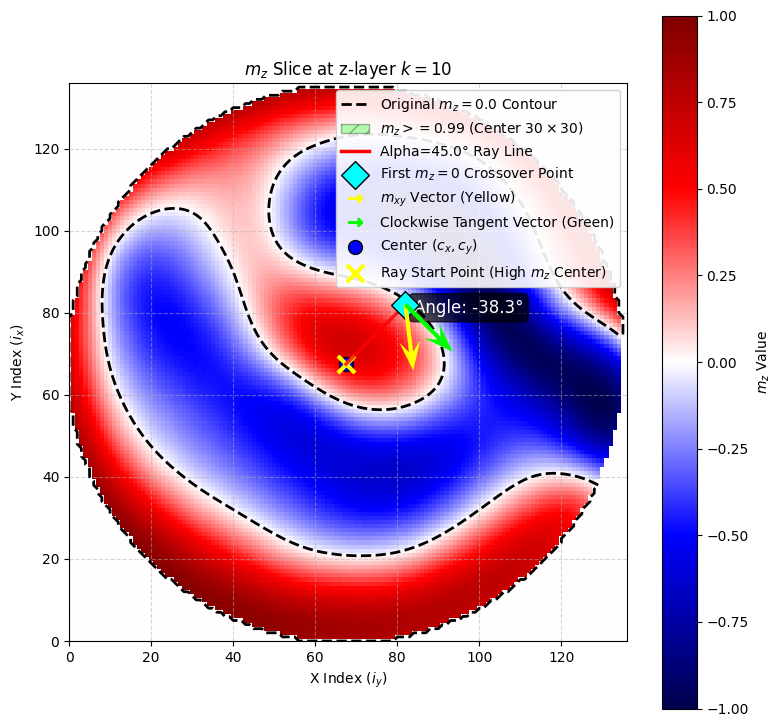

In [10]:
def visualize_for_test(spin_tensor: torch.Tensor, target_z: int, alpha_degree: float = 45.0, target_mz: float = 0.0):
    """
    visualize the spin tensor slice at a specific z layer, and draw the original target_mz isosurface.

    spin_tensor: the input spin tensor with shape (3, nx, ny, nz).
    target_mz: the mz isovalue for segmentation.
    alpha_degree: the angle of the ray to be drawn.
    target_z: the z layer index to visualize.
    """
    if spin_tensor.dim() != 4 or spin_tensor.shape[0] != 3:
        raise ValueError("Input tensor shape must be (3, nx, ny, nz)")

    spin = spin_tensor.detach().cpu().numpy()
    mx_slice = spin[0, :, :, target_z] # (nx, ny)
    my_slice = spin[1, :, :, target_z] # (nx, ny)
    mz_slice = spin[2, :, :, target_z] # (nx, ny)
    _, nx, ny, nz = spin.shape
    
    if not (0 <= target_z < nz):
        raise ValueError(f"target_z {target_z} is out of bounds [0, {nz-1}]")
        
    cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0
    X, Y = np.meshgrid(np.arange(ny), np.arange(nx), indexing='xy')
    
    N_limit = 30    # the size of the center area to restrict high mz values
    N_half = N_limit // 2
    cx_int, cy_int = int(round(cx)), int(round(cy))
  
    ix_start = max(0, cx_int - N_half)
    ix_end = min(nx, cx_int + N_half)
    iy_start = max(0, cy_int - N_half)
    iy_end = min(ny, cy_int + N_half)

    high_mz_indices = np.where(mz_slice >= 0.99) # (ix_coords, iy_coords)

    valid_mask = (high_mz_indices[0] >= ix_start) & (high_mz_indices[0] < ix_end) & \
                 (high_mz_indices[1] >= iy_start) & (high_mz_indices[1] < iy_end)
    
    filtered_ix = high_mz_indices[0][valid_mask]
    filtered_iy = high_mz_indices[1][valid_mask]

    if filtered_ix.size == 0:
        start_x, start_y = cx, cy
        print("Warning: No $m_z \\ge 0.99$ point found in the restricted center area. Ray starts at the geometric center.")
    else:
        start_x = np.mean(filtered_ix)
        start_y = np.mean(filtered_iy)
        print(f"Ray Start Point (Geometric Center of $m_z \\ge 0.99$ region): ({start_x:.2f}, {start_y:.2f})")

    plt.figure(figsize=(9, 9))
    im = plt.pcolormesh(Y, X, mz_slice, cmap='seismic', vmin=-1.0, vmax=1.0)
    plt.colorbar(im, label='$m_z$ Value')
    legend_handles = []
    legend_labels = []

    contour_line = plt.contour(
        Y, X, mz_slice, 
        levels=[target_mz], 
        colors='black', 
        linewidths=2, 
        linestyles='--'
    )
    legend_handles.append(Line2D([0], [0], color='black', linewidth=2, linestyle='--'))
    legend_labels.append(f'Original $m_z={target_mz}$ Contour') 

    mz_masked = mz_slice.copy()
    mask_grid = np.zeros_like(mz_slice, dtype=bool)
    mask_grid[ix_start:ix_end, iy_start:iy_end] = True
    mz_masked[~mask_grid] = np.nan 

    contour_fill = plt.contourf(
        Y, X, mz_masked, 
        levels=[0.99, 1.0], 
        colors='lime',
        alpha=0.3,
        hatches=['//'] 
    )
    
    legend_handles.append(Patch(facecolor='lime', edgecolor='black', alpha=0.3, hatch='//'))
    legend_labels.append('$m_z >= 0.99$ (Center $30 \\times 30$)')

    alpha_radian = np.deg2rad(alpha_degree)
    cos_a, sin_a = np.cos(alpha_radian), np.sin(alpha_radian)

    ray_x_float, ray_y_float = [start_x], [start_y]

    ray_ix_path = []
    ray_iy_path = []

    intersection_point = None 

    for r in np.linspace(0.1, max(nx, ny) * 1.5, 200):
        next_x_pos = start_x + r * cos_a
        next_y_pos = start_y + r * sin_a

        if 0 <= next_x_pos < nx and 0 <= next_y_pos < ny:
            ray_x_float.append(next_x_pos)
            ray_y_float.append(next_y_pos)

            ix = int(round(next_x_pos))
            iy = int(round(next_y_pos))

            if not ray_ix_path or ix != ray_ix_path[-1] or iy != ray_iy_path[-1]:
                ray_ix_path.append(ix)
                ray_iy_path.append(iy)

                if len(ray_ix_path) > 1:
                    i_x_prev, i_y_prev = ray_ix_path[-2], ray_iy_path[-2]
                    
                    mz_prev = mz_slice[i_x_prev, i_y_prev]
                    mz_curr = mz_slice[ix, iy]

                    if mz_prev > target_mz and mz_curr <= target_mz:
                        intersection_point = (i_x_prev, i_y_prev)
                        print(f"Intersection found at index: ({i_x_prev}, {i_y_prev}) with $m_z$={mz_prev:.3f}")
                        break
        else:
            break
            
    ray_line = plt.plot(ray_x_float, ray_y_float, color='red', linestyle='-', linewidth=2.5, alpha=0.8)
    legend_handles.append(Line2D([0], [0], color='red', linewidth=2.5))
    legend_labels.append(f'Alpha={alpha_degree}° Ray Line')

    if intersection_point is not None:
        ix_intersect, iy_intersect = intersection_point
        intersect_scatter = plt.scatter(ix_intersect, iy_intersect, color='cyan', marker='D', s=200, edgecolors='black', zorder=5)

        # draw m_xy vector at the intersection point
        mx_val = mx_slice[ix_intersect, iy_intersect]
        my_val = my_slice[ix_intersect, iy_intersect]
        quiver_mxy = plt.quiver(
            ix_intersect, iy_intersect, 
            mx_val, my_val, 
            color='yellow', 
            scale=1.5, 
            scale_units='inches', 
            headwidth=5, 
            headlength=7,
            zorder=6,
            label='$m_{xy}$ Vector'
        )
        
        # draw tangent vector at the intersection point
        R_x = ix_intersect - start_x
        R_y = iy_intersect - start_y
        T_x = R_y
        T_y = -R_x

        norm_T = np.sqrt(T_x**2 + T_y**2)
        if norm_T > 0:
            T_x_norm = T_x / norm_T
            T_y_norm = T_y / norm_T
        else:
            T_x_norm, T_y_norm = 0, 0

        quiver_tangent = plt.quiver(
            ix_intersect, iy_intersect, 
            T_x_norm, T_y_norm, 
            color='lime', 
            scale=1.5, 
            scale_units='inches', 
            headwidth=5, 
            headlength=7,
            zorder=6,
            label='Clockwise Tangent'
        )

        # calculate angle between tangent vector T and m_xy vector
        m_xy_magnitude = np.sqrt(mx_val**2 + my_val**2)
        if m_xy_magnitude > 0:
            mx_norm = mx_val / m_xy_magnitude
            my_norm = my_val / m_xy_magnitude
        else:
            mx_norm, my_norm = 0, 0

        dot_product = T_x_norm * mx_norm + T_y_norm * my_norm
        cross_product = T_x_norm * my_norm - T_y_norm * mx_norm  
        angle_rad = np.arctan2(cross_product, dot_product)
        angle_deg = np.degrees(angle_rad)

        if angle_deg > 180:
            angle_deg -= 360
        elif angle_deg < -180:
            angle_deg += 360

        print(f"\nAngle Calculation:")
        print(f"  Tangent Vector (normalized): ({T_x_norm:.3f}, {T_y_norm:.3f})")
        print(f"  m_xy Vector (normalized): ({mx_norm:.3f}, {my_norm:.3f})")
        print(f"  Dot Product: {dot_product:.3f}")
        print(f"  Cross Product: {cross_product:.3f}")
        print(f"  Angle between vectors: {angle_deg:.2f}°")

        angle_text = f"Angle: {angle_deg:.1f}°"
        plt.text(iy_intersect + 2, ix_intersect - 2, angle_text, 
                fontsize=12, color='white', backgroundcolor='black', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

        legend_handles.append(intersect_scatter)
        legend_labels.append('First $m_z=0$ Crossover Point')

        legend_handles.append(Line2D([0], [0], color='yellow', linewidth=0, marker=r'$\rightarrow$', markersize=10))
        legend_labels.append(f'$m_{{xy}}$ Vector (Yellow)')

        legend_handles.append(Line2D([0], [0], color='lime', linewidth=0, marker=r'$\rightarrow$', markersize=10))
        legend_labels.append(f'Clockwise Tangent Vector (Green)')

    center_scatter = plt.scatter(cx, cy, color='blue', marker='o', s=100, edgecolors='black')
    legend_handles.append(center_scatter)
    legend_labels.append('Center $(c_x, c_y)$')
    
    start_scatter = plt.scatter(start_x, start_y, color='yellow', marker='x', s=150, linewidths=3, edgecolors='black')
    legend_handles.append(start_scatter)
    legend_labels.append('Ray Start Point (High $m_z$ Center)')

    plt.title(f'$m_z$ Slice at z-layer $k={target_z}$')
    plt.xlabel('X Index ($i_y$)')
    plt.ylabel('Y Index ($i_x$)')
    
    plt.legend(handles=legend_handles, labels=legend_labels, loc='best', framealpha=0.9)
    
    plt.xlim(0, nx)
    plt.ylim(0, ny) 
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

    return angle_deg

l = 0
file_path = f'D:\\\\Projects\\TargetSkyrmion\\targetdata\\test_phi\\results\\loss{l:.1e}_wphi1.0e+07'
target_z_layer = 10
alpha_to_highlight = 45.0

try:
    spin, nx, ny, nz = get_spin(file_path)
    angle = visualize_for_test(spin, target_z_layer, alpha_to_highlight)
except Exception as e:
    print(f"Error during visualization: {e}")